# Numerical Methods for Ordinary Differential Equations
## Final Project — Part I

**Author:** Lucas Pieper-White  
**Course:** MATH 104C - Spring 2026
**Date:** June 5th, 2026

**Code:** Github Link: [PiepBuilds/Math-104C-Final-Project](https://github.com/PiepBuilds/Math-104C-Final-Project)

---

### Introduction

This project in numerical analysis aims to implement and evaluate nine numerical methods for solving the following initial value problem.

$$y'=f(t,y) \quad \text{on } [a,b]\ \text{ with } y(a)=\alpha$$

We solve the above IVP with the following methods: Euler's, Taylor's Order 2, Midpoint, Modified Euler, Heun, Runge–Kutta Order 4, Adams–Bashforth, Adams–Moulton, and the Adams Predictor–Corrector method. The primary goal is to compare accuracy, error propagation, and computational efficiency, and to connect numerical observations with theoretical error estimates.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import approxmethods as M   # the nine solvers

# --- the three initial-value problems (defined inline so the report is self-contained) ---
PROBLEM_A = {  # smooth test problem
    'name': "A: y' = y - t^2 + 1",
    'f':     lambda t, y: y - t**2 + 1.0,
    'dfdt':  lambda t, y: y - t**2 - 2.0*t + 1.0,   # total derivative f_t + f_y f
    'exact': lambda t: (t + 1.0)**2 - 0.5*np.exp(t),
    'a': 0.0, 'b': 2.0, 'alpha': 0.5,
}
PROBLEM_B = {  # exponential error amplification
    'name': "B: y' = 2y",
    'f':     lambda t, y: 2.0*y,
    'dfdt':  lambda t, y: 4.0*y,
    'exact': lambda t: np.exp(2.0*t),
    'a': 0.0, 'b': 2.0, 'alpha': 1.0,
}
PROBLEM_C = {  # rapid decay with forcing (instructor's suggested example)
    'name': "C: y' = -10y + sin t",
    'f':     lambda t, y: -10.0*y + np.sin(t),
    'dfdt':  lambda t, y: np.cos(t) + 100.0*y - 10.0*np.sin(t),  # f_t + f_y f
    'exact': lambda t: (10.0*np.sin(t) - np.cos(t))/101.0 + (102.0/101.0)*np.exp(-10.0*t),
    'a': 0.0, 'b': 2.0, 'alpha': 1.0,
}

print('exact checks:  A:y(2)=%.6f   B:y(2)=%.6f   C:y(2)=%.6f'
      % (PROBLEM_A['exact'](2), PROBLEM_B['exact'](2), PROBLEM_C['exact'](2)))

exact checks:  A:y(2)=5.305472   B:y(2)=54.598150   C:y(2)=0.094150


## Numerical Methods

All of the methods used in this report approximate the solution on a uniform mesh defined by $t_i = a + ih$, producing approximations $w_i$ for $y(t_i)$. We separate the methods into single-step methods and multi-step methods.

### Single-Step Methods

The single-step methods (Euler, Taylor, Midpoint, Modified Euler, Heun, RK4) compute $w_{i+1}$ using only the most recent point $w_i$.

**Euler's Method:** Euler's method takes the slope at the left endpoint and follows that tangent line to the next mesh point, repeating the tangent-line extension from each new left point. Because the solution curves away from the tangent line within each step, Euler's method has Local Truncation Error (LTE) $O(h^2)$ and Global Error $O(h)$.

$$w_{i+1}=w_i+h\,f(t_i,w_i)$$

**Taylor's Method (Order 2):** Taylor's method includes $y''$ through the total derivative $f' = \tfrac{df}{dt} = f_t + f_y\,f$, giving more accuracy than Euler's method, which uses only $f$. The cost is that the derivative $f'$ must be computed by hand, making the method tedious and expensive compared to the others. Taylor's method of order 2 has LTE $O(h^3)$ and Global Error $O(h^2)$.

$$w_{i+1}=w_i+h\left(f(t_i,w_i)+\tfrac{h}{2}f'(t_i,w_i)\right)$$

**Midpoint Method (RK2, Order 2):** The midpoint method uses the left-endpoint slope to estimate the midpoint, then samples the slope again there to take the full step, capturing more curvature than Euler's left-endpoint slope alone. It has LTE $O(h^3)$ and Global Error $O(h^2)$, and is light on computation — only function evaluations, no derivatives.

$$w_{i+1}=w_i+h\,f\!\left(t_i+\tfrac{h}{2},\,w_i+\tfrac{h}{2}f(t_i,w_i)\right)$$

**Modified Euler's Method (RK2, Order 2):** Modified Euler samples the slope at the left endpoint and at the predicted full-step right endpoint, then advances using the average of those two slopes. It has LTE $O(h^3)$ and Global Error $O(h^2)$.

$$w_{i+1}=w_i+\tfrac{h}{2}\left(f(t_i,w_i)+f(t_i+h,\,w_i+h\,f(t_i,w_i))\right)$$

**Heun's Method (RK3, Order 3):** Heun's method is a weighted combination of three slope evaluations — the left endpoint, an intermediate point, and a predicted point — combined with weights $\left(\tfrac{1}{4},0,\tfrac{3}{4}\right)$, which cancels the error terms up to higher order. It has LTE $O(h^4)$ and Global Error $O(h^3)$.

$$w_{i+1}=w_i+\tfrac{h}{4}(k_1+3k_3)$$

$$k_1=f(t_i,w_i),\qquad k_2=f\!\left(t_i+\tfrac{h}{3},\,w_i+\tfrac{h}{3}k_1\right),\qquad k_3=f\!\left(t_i+\tfrac{2h}{3},\,w_i+\tfrac{2h}{3}k_2\right)$$

**Classical Runge–Kutta (RK4, Order 4):** RK4 samples the slope at four points within each step — the left endpoint, two midpoint estimates, and the right endpoint — and combines them with weights $\left(\tfrac{1}{6},\tfrac{2}{6},\tfrac{2}{6},\tfrac{1}{6}\right)$. This reproduces the accuracy of an order-4 Taylor method using only function evaluations, with no hand-computed derivatives. RK4 has LTE $O(h^5)$ and Global Error $O(h^4)$, making it the most accurate single-step method here, at the cost of four function evaluations per step.

$$w_{i+1}=w_i+\tfrac{h}{6}(k_1+2k_2+2k_3+k_4)$$

$$k_1=f(t_i,w_i),\qquad k_2=f\!\left(t_i+\tfrac{h}{2},\,w_i+\tfrac{h}{2}k_1\right),\qquad k_3=f\!\left(t_i+\tfrac{h}{2},\,w_i+\tfrac{h}{2}k_2\right),\qquad k_4=f(t_i+h,\,w_i+h\,k_3)$$

### Multi-Step Methods

The multi-step methods are started with RK4 and then reuse previously computed slopes rather than recomputing everything each step. Throughout, $f_i \equiv f(t_i, w_i)$ denotes the slope already stored from earlier steps.

**Adams–Bashforth 4-Step (Explicit, Order 4):** Adams–Bashforth fits an interpolating polynomial through the four most recent slopes $f_i, f_{i-1}, f_{i-2}, f_{i-3}$ and integrates it across the next step. It needs only one new function evaluation per step, which is what makes it explicit and cheap. It has Global Error $O(h^4)$. Its weakness is that it extrapolates beyond the known data, so it is comparatively inaccurate and, as we will see, prone to instability.

$$w_{i+1}=w_i+\tfrac{h}{24}\left(55f_i-59f_{i-1}+37f_{i-2}-9f_{i-3}\right)$$

**Adams–Moulton 3-Step (Implicit, Order 4):** Adams–Moulton again interpolates a polynomial through recent slopes, but instead of extrapolating it includes the unknown $f_{i+1}$, making it implicit and more stable. The unknown $w_{i+1}$ appears on both sides through $f_{i+1}=f(t_{i+1},w_{i+1})$, so it must be solved iteratively, which is more costly. It has Global Error $O(h^4)$.

$$w_{i+1}=w_i+\tfrac{h}{24}\left(9f_{i+1}+19f_i-5f_{i-1}+f_{i-2}\right)$$

**Adams Predictor–Corrector (ABM4, Order 4):** The predictor–corrector method gets most of the accuracy of the implicit method at a fixed cost. It first *predicts* $w_{i+1}^{(p)}$ with the explicit Adams–Bashforth formula, then *corrects* by evaluating the slope there once and substituting it into the Adams–Moulton formula. This avoids the iterative solve while keeping order-4 accuracy at a fixed cost of two function evaluations per step. It has Global Error $O(h^4)$.

$$w_{i+1}^{(p)}=w_i+\tfrac{h}{24}\left(55f_i-59f_{i-1}+37f_{i-2}-9f_{i-3}\right)$$

$$w_{i+1}=w_i+\tfrac{h}{24}\left(9\,f(t_{i+1},w_{i+1}^{(p)})+19f_i-5f_{i-1}+f_{i-2}\right)$$


### **Error Metrics and Experimental Setup**

Every method is run on a uniform mesh $t_i = a + ih$ for $i = 0, 1, \dots, N$, where $N = (b-a)/h$ is the number of steps and $w_i$ denotes the method's approximation to the exact Solution $y(t_i)$, with $w_0 = \alpha$. Each problem is run at $h = 0.2,\ 0.1,\ 0.05$.

Where an exact Solution is known, the absolute Error at each Mesh point is

$$e_i = |y(t_i) - w_i|,$$

and each problems summary table includes the maximum absolute error over the mesh,

$$E(h) = \max_{0 \le i \le N} |y(t_i) - w_i|.$$

For Problem B the solution grows large, so we also report the relative error $|y(t_i) - w_i| / |y(t_i)|$, which measures error against the size of the Solution rather than in absolute terms.

The observed order of convergence is recovered from these maximum Errors. Since the Global Error is expected to behave like $E(h) \approx C h^p$ for a method of Order $p$, halving the Step gives $E(h)/E(h/2) \approx 2^p$, thus as seen in lecture.

$$p \approx \log_2\!\left(\frac{E(h)}{E(h/2)}\right).$$

This is computed only from the Error data, with no assumed value of $p$, so it serves as an independent check on each Method's predicted Order. The convergence plots show $E(h)$ against $h$ on log–log axes, where this relationship makes each Method a roughly straight line of slope $p$.

For the stiff Problem C, a run is flagged unstable when the numerical Solution grows far beyond the size of the true Solution, specifically when $\max_i |w_i|$ exceeds ten times $\max_t |y(t)|$, which separates Methods that stay bounded from those that diverge.

### Experiment helpers

Small reusable functions: run every method at a given step size, build the exact/approx/error table, and compute observed order of convergence. These are reused unchanged for all three problems.

In [28]:
STEPS = [0.2, 0.1, 0.05]
METHODS = ['Euler','Taylor 2','Midpoint','Modified Euler','Heun (RK3)','RK4',
           'Adams-Bashforth 4','Adams-Moulton 3','Predictor-Corrector']

def run_all(P, h):
    f, dfdt, a, b, al = P['f'], P['dfdt'], P['a'], P['b'], P['alpha']
    return {
        'Euler':               M.euler(f,a,b,al,h),
        'Taylor 2':            M.taylor2(f,dfdt,a,b,al,h),
        'Midpoint':            M.midpoint(f,a,b,al,h),
        'Modified Euler':      M.modified_euler(f,a,b,al,h),
        'Heun (RK3)':          M.heun(f,a,b,al,h),
        'RK4':                 M.rk4(f,a,b,al,h),
        'Adams-Bashforth 4':   M.adams_bashforth4(f,a,b,al,h),
        'Adams-Moulton 3':     M.adams_moulton3(f,a,b,al,h),
        'Predictor-Corrector': M.predictor_corrector(f,a,b,al,h),
    }

def max_err(P, h):
    R = run_all(P, h)
    return {m: np.max(np.abs(P['exact'](t) - w)) for m,(t,w) in R.items()}

def order_table(P):
    e = {h: max_err(P, h) for h in STEPS}
    rows = []
    for m in METHODS:
        p1 = np.log2(e[0.2][m]/e[0.1][m]) if e[0.1][m] > 0 else np.nan
        p2 = np.log2(e[0.1][m]/e[0.05][m]) if e[0.05][m] > 0 else np.nan
        rows.append([m, e[0.2][m], e[0.1][m], e[0.05][m], p1, p2])
    df = pd.DataFrame(rows, columns=['method','max|err| h=0.2','max|err| h=0.1',
                                     'max|err| h=0.05','order .2->.1','order .1->.05'])
    return df

def per_mesh_df(P, h, m):
    """Burden & Faires style per-point table for one method: t, y(t_i), w_i, |error|."""
    t, w = run_all(P, h)[m]; ye = P['exact'](t)
    return pd.DataFrame({'t': t, 'y(t_i)': ye, 'w_i': w, '|error|': np.abs(ye-w)})

from IPython.display import display, HTML

_CSS = '''<style>
.mini {display:flex; flex-wrap:wrap; gap:10px; margin-bottom:14px;}
.mini .card {font-size:10px;}
.mini .cap {font-weight:600; font-size:11px; margin-bottom:2px;}
.mini table {border-collapse:collapse;}
.mini th,.mini td {border:1px solid #bbb; padding:1px 5px; text-align:right;}
</style>'''

def show_all_tables(P, h):
    """Render all nine methods' per-mesh tables in a compact grid, summary table below."""
    cards = ''
    for m in METHODS:
        tbl = per_mesh_df(P, h, m).round(6).to_html(index=False, border=0)
        cards += f'<div class="card"><div class="cap">{m}</div>{tbl}</div>'
    display(HTML(f'{_CSS}<b>Per-mesh tables at h={h} (t, exact, approximation, absolute error)</b>'
                 f'<div class="mini">{cards}</div>'))
    oc = order_table(P).set_index('method')
    fmt = {c:'{:.3e}' for c in oc.columns[:3]}; fmt.update({'order .2->.1':'{:.2f}','order .1->.05':'{:.2f}'})
    display(HTML('<b>Summary: max absolute error over mesh and observed order of convergence</b>'))
    display(oc.style.format(fmt))

## Problem A — Smooth Test Problem

$$y' = y - t^2 + 1,\quad 0\le t\le 2,\quad y(0)=0.5,\qquad \text{exact: } y(t)=(t+1)^2-\tfrac12 e^{t}.$$

This smooth problem is used to measure accuracy and observed order of convergence.

In [29]:
# all nine per-mesh tables (compact grid) with the summary table below
show_all_tables(PROBLEM_A, 0.2)

t,y(t_i),w_i,|error|
0.0,0.500000,0.500000,0.000000
0.2,0.829299,0.800000,0.029299
0.4,1.214088,1.152000,0.062088
0.6,1.648941,1.550400,0.098541
0.8,2.127230,1.988480,0.138750
1.0,2.640859,2.458176,0.182683
1.2,3.179942,2.949811,0.230130
1.4,3.732400,3.451773,0.280627
1.6,4.283484,3.950128,0.333356
1.8,4.815176,4.428154,0.387023


,max|err| h=0.2,max|err| h=0.1,max|err| h=0.05,order .2->.1,order .1->.05
method,,,,,
Euler,4.397e-01,2.420e-01,1.275e-01,0.86,0.92
Taylor 2,4.221e-02,1.141e-02,2.964e-03,1.89,1.94
Midpoint,1.510e-02,3.747e-03,9.277e-04,2.01,2.01
Modified Euler,7.242e-02,1.890e-02,4.820e-03,1.94,1.97
Heun (RK3),4.797e-04,5.734e-05,7.015e-06,3.06,3.03
RK4,1.089e-04,6.990e-06,4.421e-07,3.96,3.98
Adams-Bashforth 4,2.036e-03,1.846e-04,1.368e-05,3.46,3.75
Adams-Moulton 3,2.703e-04,1.831e-05,1.184e-06,3.88,3.95
Predictor-Corrector,1.013e-04,1.093e-05,9.132e-07,3.21,3.58


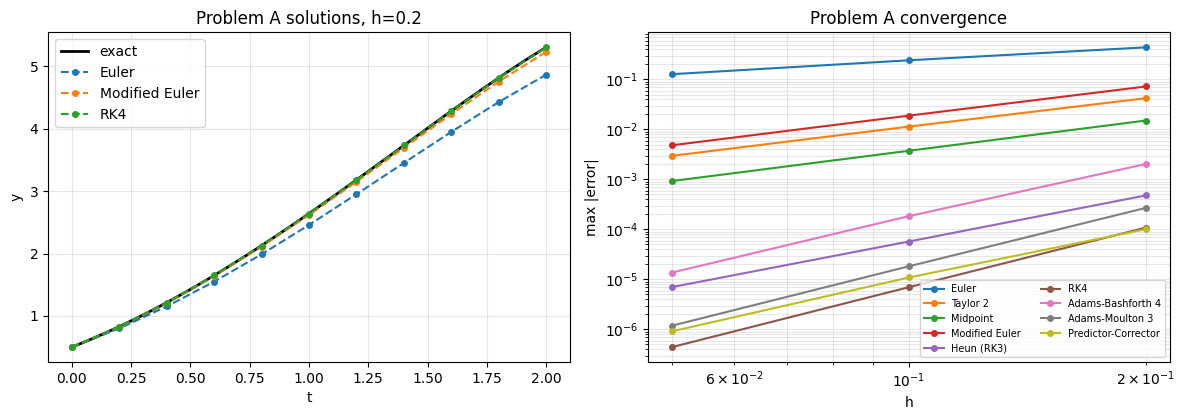

In [30]:
# solution overlay + convergence
fig, ax = plt.subplots(1, 2, figsize=(12,4.3))
tt = np.linspace(0,2,400); ax[0].plot(tt, PROBLEM_A['exact'](tt),'k-',lw=2,label='exact')
for m in ['Euler','Modified Euler','RK4']:
    t,w = run_all(PROBLEM_A,0.2)[m]; ax[0].plot(t,w,'o--',ms=4,label=m)
ax[0].set(title='Problem A solutions, h=0.2', xlabel='t', ylabel='y'); ax[0].legend(); ax[0].grid(alpha=.3)
e = {h: max_err(PROBLEM_A,h) for h in STEPS}
for m in METHODS: ax[1].loglog(STEPS,[e[h][m] for h in STEPS],'o-',ms=4,label=m)
ax[1].set(title='Problem A convergence', xlabel='h', ylabel='max |error|'); ax[1].legend(fontsize=7,ncol=2); ax[1].grid(alpha=.3,which='both')
plt.tight_layout(); plt.show()

### **Problem A: Smooth Test Problem**

**Hand Verification (Euler, $h=0.2$).** First we check code the implementation, the first Euler steps computed by hand from $w_{i+1}=w_i+hf(t_i,w_i)$ with $f=y-t^2+1$ give $w_1=0.8$, $w_2=1.152$, $w_3=1.5504$, matching our output exactly. The exact value $y(2)=(2{+}1)^2-\tfrac12 e^2=5.305472$ also matches the table, confirming both the approximations and the reported errors.

**Results Discussion:** Across all nine Methods the measured order matches up with the predicted order almost exactly.At $h=0.2$ the max Global Error runs from $4.4\times10^{-1}$ (Euler) down to $1.1\times10^{-4}$ (RK4), roughly a $10^{4}$ spread between the worst, Eulers Method the and best, Runge-Kutta 4 Method all on the same mesh.

Following what we learned in lecture, halving $h$ should scale the Error by about $\frac{1}{2}^p$, so the measured order is recovered as $p \approx \log_2\!(\frac{\text{Error}(h)}{\text{Error}(h/2))}$. For Euler, the error falls from $4.397\times10^{-1}$ to $2.420\times10^{-1}$ as $h$ goes 0.2 to 0.1, a ratio of only $1.82$, giving $\log_2(1.82)=0.86\approx1$ : halving $h$ barely helps, exactly what an Order-1 Method does. For RK4 under the same refining the Error drops from $1.089\times10^{-4}$ to $6.990\times10^{-6}$, a ratio of $15.6\approx2^4$, giving $\log_2(15.6)=3.96\approx4$. In the convergence plot, we can also see the Euler and RK4 methods as our best and worst methods forming upper and lower bounds for the other methods. Comparing the order calculations in the above summary table to the predicted convergence orders defined in the methods section we find that Taylor 2, Midpoint, and Modified Euler all are close to 2, Midpoint almost exact at $2.01$, and Heun measures $3.06, 3.03\approx3$. Since each measured exponent is built only from the Error data and still settles onto the integer order predicted in the methods section, this is confirmation that the global Error behaves like $O(h^p)$ as predicted.

The three multistep Methods are not so exact, they land slightly below 4 as $h$ goes from 0.2 to 0/1. Adams–Bashforth comes in at 3.46, and Predictor–Corrector at 3.21. Despite this, they get closer to 4 as as $h$ shrinks again 3.75 and 3.58. This is feature is somewhat expected given how we built them since each is started by RK4 for its first few Steps, so a little Error in the beginning carries on and drags the measured exponent under 4 at the coarser step sizes but coming back under refinement.

The reason RK4 dominates Eulers in Problem A is because of how they calculate slope and project forward. Euler uses only the left endpoint slope to move forward the entire  step, so any deviation from that slope inside the interval is ignored and feeds straight into the Local Truncation Error, leaving Global Error at $O(h)$. RK4 samples four slopes per step; the left endpoint, two midpoints, and the right endpoint, then takes a weighted average and capturing curvature and retaining global Error $O(h^4)$. RK4 pays for this with four function evaluations per Step against Euler's one, but on a smooth problem the high order lets us hit a target accuracy in far fewer, larger steps, winning by orders of magnitude anyway.

## Problem B — Error Amplification

$$y' = 2y,\quad 0\le t\le 2,\quad y(0)=1,\qquad \text{exact: } y(t)=e^{2t}.$$

Because the true solution grows exponentially, we expect early errors to be amplified over time.

In [31]:
# all nine per-mesh tables (compact grid) with the summary table below
show_all_tables(PROBLEM_B, 0.2)

t,y(t_i),w_i,|error|
0.0,1.000000,1.000000,0.000000
0.2,1.491825,1.400000,0.091825
0.4,2.225541,1.960000,0.265541
0.6,3.320117,2.744000,0.576117
0.8,4.953032,3.841600,1.111432
1.0,7.389056,5.378240,2.010816
1.2,11.023176,7.529536,3.493640
1.4,16.444647,10.541350,5.903296
1.6,24.532530,14.757891,9.774640
1.8,36.598234,20.661047,15.937188


,max|err| h=0.2,max|err| h=0.1,max|err| h=0.05,order .2->.1,order .1->.05
method,,,,,
Euler,2.567e+01,1.626e+01,9.339e+00,0.66,0.80
Taylor 2,4.176e+00,1.241e+00,3.367e-01,1.75,1.88
Midpoint,4.176e+00,1.241e+00,3.367e-01,1.75,1.88
Modified Euler,4.176e+00,1.241e+00,3.367e-01,1.75,1.88
Heun (RK3),4.223e-01,6.203e-02,8.401e-03,2.77,2.88
RK4,3.343e-02,2.466e-03,1.675e-04,3.76,3.88
Adams-Bashforth 4,7.306e-01,7.630e-02,6.045e-03,3.26,3.66
Adams-Moulton 3,7.999e-02,6.850e-03,4.977e-04,3.55,3.78
Predictor-Corrector,4.114e-02,5.501e-04,2.443e-04,6.22,1.17


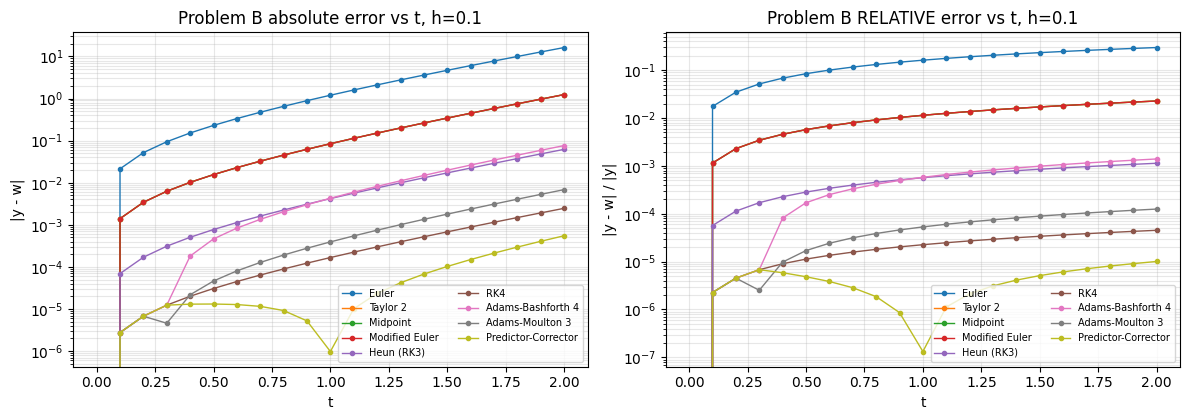

In [32]:
# absolute error grows, but relative error stays bounded
fig, ax = plt.subplots(1, 2, figsize=(12,4.3))
R = run_all(PROBLEM_B,0.1)
for m in METHODS:
    t,w = R[m]; ax[0].semilogy(t, np.abs(PROBLEM_B['exact'](t)-w),'o-',ms=3,lw=1,label=m)
ax[0].set(title='Problem B absolute error vs t, h=0.1', xlabel='t', ylabel='|y - w|'); ax[0].legend(fontsize=7,ncol=2); ax[0].grid(alpha=.3,which='both')
for m in METHODS:
    t,w = R[m]; ye = PROBLEM_B['exact'](t); ax[1].semilogy(t, np.abs((ye-w)/ye),'o-',ms=3,lw=1,label=m)
ax[1].set(title='Problem B RELATIVE error vs t, h=0.1', xlabel='t', ylabel='|y - w| / |y|'); ax[1].legend(fontsize=7,ncol=2); ax[1].grid(alpha=.3,which='both')
plt.tight_layout(); plt.show()

### **Problem B: Error Amplification**

In Problem B the exact solution $y=e^{2t}$ reaches 54.60 at $t=2$ so absolute errors are large by construction. At $h=0.2$ Euler gives $w(2)=28.93$ vs exact 54.60, an absolute error of 25.67, large because the solution is large. The relative error $\frac{|y-w|}{|y|}$ is more meaningful: for Euler it is (0.47, 0.30, 0.17) across $h=0.2, 0.1, 0.05$, and for RK4 we have $6.1\times10^{-4}$ down to $3.1\times10^{-6}$. Relative Error stays bounded and shrinks with h, so the Methods are not failing. As noted in the methods section, the Global Error is the accumulation of each Step's Local Truncation Error; here each step's error is carried forward and amplified by the same exponential growth as the true solution, so absolute Error grows while relative Error stays under control. This is error propagation in a growing problem. The problem is still well-posed however, the errors are amplified but stay bounded relative to the solution; small changes in the problem lead to small changes in the solution.

Taylors order 2, Midpoint, and Modified Euler give identical errors at every step size coming in at $(4.176, 1.241, 0.337)$. Comparing the iteration schemes outlined in the methods section, for the linear problem $y'=2y$ all three order 2 methods reduce to the same update which is the amplification factor $(1+2h+2h^2)$; their distinct slope samplings (Midpoint's half-step, Modified Euler's endpoint average) collapse to the same recurrence once $f=2y$ is substituted. We see that they are not only the same order, they are the same method. This is the concrete example where the order exponent $p$ is shared but the problem itself removes the leading constant.

Also notice in the plot and summary table that the easured orders trend to their predicted values but slower than in Problem A: Euler $0.66, 0.80$ toward 1, the order 2 trio $1.75, 1.88$ toward 2, RK4 $3.76, 3.88$ toward 4. Because the solution is growing, the measured orders approach their integer values more slowly than in Problem A.

## Problem C — Rapid Decay with Forcing (Stability)

$$y' = -10y + \sin t,\quad 0\le t\le 2,\quad y(0)=1.$$

This is a linear first-order ODE, so it has a closed-form solution. Using the integrating factor $e^{10t}$,

$$y(t) = \frac{10\sin t - \cos t}{101} + \frac{102}{101}e^{-10t}.$$

I chose this problem to study stability rather than accuracy. The $-10y$ term makes the Solution decay rapidly from $1$ before settling into a small oscillation driven by $\sin t$. For an explicit Method the key quantity is $h\lambda = -10h$, and forward Euler is stable only when $|1+h\lambda| \le 1$, that is $h \le 2/10 = 0.2$. So I expected the explicit Methods to handle $h=0.2$ poorly and to improve sharply as $h$ shrinks.

In [33]:
# all nine per-mesh tables (compact grid) with the summary table below
show_all_tables(PROBLEM_C, 0.2)

# stability flag: a run is UNSTABLE if it grows far beyond the true solution's size
yref = np.max(np.abs(PROBLEM_C['exact'](np.linspace(PROBLEM_C['a'],PROBLEM_C['b'],400))))
rows = []
for h in STEPS:
    R = run_all(PROBLEM_C,h)
    rows.append([h] + ['stable' if np.max(np.abs(w)) <= 10*yref else 'UNSTABLE'
                        for m in METHODS for (t,w) in [R[m]]])
display(HTML('<b>Stability: which methods stay bounded at each step size</b>'))
display(pd.DataFrame(rows, columns=['h']+METHODS).set_index('h').T)
print('Euler stable iff h <= 2/10 = 0.2')

t,y(t_i),w_i,|error|
0.0,1.000000,1.000000,0.000000
0.2,0.146642,-1.000000,1.146642
0.4,0.047934,1.039734,0.991800
0.6,0.050237,-0.961850,1.012087
0.8,0.064466,1.074779,1.010313
1.0,0.078010,-0.931307,1.009318
1.2,0.088700,1.099602,1.010902
1.4,0.095887,-0.913194,1.009081
1.6,0.099257,1.110284,1.011027
1.8,0.098670,-0.910369,1.009039


,max|err| h=0.2,max|err| h=0.1,max|err| h=0.05,order .2->.1,order .1->.05
method,,,,,
Euler,1.147e+00,3.716e-01,1.191e-01,1.63,1.64
Taylor 2,1.011e+00,1.334e-01,2.297e-02,2.92,2.54
Midpoint,1.009e+00,1.334e-01,2.297e-02,2.92,2.54
Modified Euler,1.007e+00,1.334e-01,2.297e-02,2.92,2.54
Heun (RK3),4.734e-01,3.489e-02,2.891e-03,3.76,3.59
RK4,2.000e-01,7.192e-03,2.943e-04,4.80,4.61
Adams-Bashforth 4,1.062e+03,8.368e+04,6.230e+02,-6.30,7.07
Adams-Moulton 3,2.000e-01,7.192e-03,2.943e-04,4.80,4.61
Predictor-Corrector,8.196e-01,2.416e-02,1.179e-03,5.08,4.36


h,0.20,0.10,0.05
Euler,stable,stable,stable
Taylor 2,stable,stable,stable
Midpoint,stable,stable,stable
Modified Euler,stable,stable,stable
Heun (RK3),stable,stable,stable
RK4,stable,stable,stable
Adams-Bashforth 4,UNSTABLE,UNSTABLE,UNSTABLE
Adams-Moulton 3,stable,stable,stable
Predictor-Corrector,stable,stable,stable


Euler stable iff h <= 2/10 = 0.2


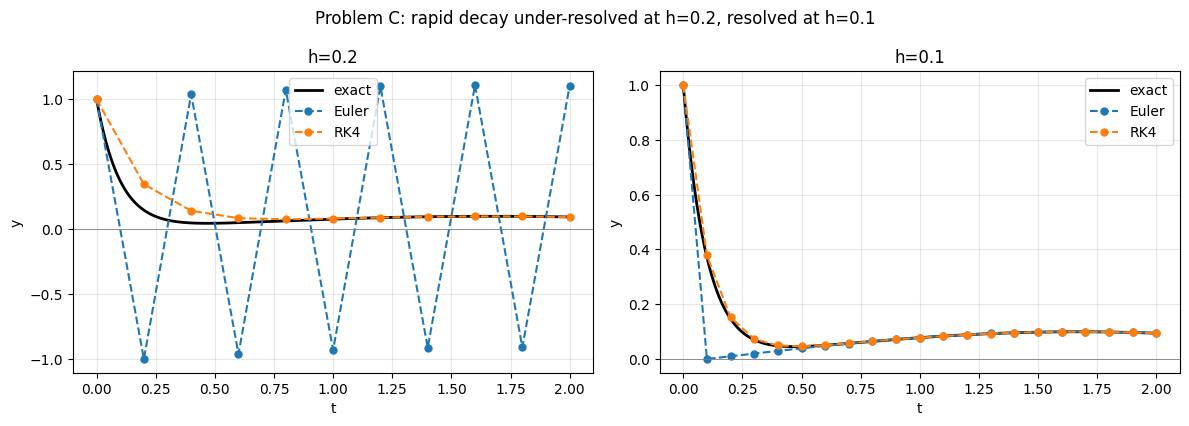

In [34]:
# the fast decay is under-resolved at h=0.2 but well-resolved at h=0.1
fig, ax = plt.subplots(1, 2, figsize=(12,4.3)); tt = np.linspace(0,2,400)
for j,h in enumerate([0.2,0.1]):
    R = run_all(PROBLEM_C,h); ax[j].plot(tt, PROBLEM_C['exact'](tt),'k-',lw=2,label='exact')
    for m in ['Euler','RK4']:
        t,w = R[m]; ax[j].plot(t,w,'o--',ms=5,label=m)
    ax[j].axhline(0,color='gray',lw=.6); ax[j].set(title=f'h={h}', xlabel='t', ylabel='y'); ax[j].legend(); ax[j].grid(alpha=.3)
fig.suptitle('Problem C: rapid decay under-resolved at h=0.2, resolved at h=0.1'); plt.tight_layout(); plt.show()

### **Problem C: Rapid Decay with Forcing**

In Problem C, we are testing stability. The $-10y$ term gives a decay timescale of $1/10$, so at $h=0.2$ even RK4 has an Error of 0.200, versus $1.1\times10^{-4}$ on Problem A at the same $h$.A step that large cannot capture the fast decay, so the same method that was accurate on Problem A is not here.

Euler shows the stability bound well. Taking the Euler scheme from the methods section, $w_{i+1}=w_i+hf$, and substituting $f=\lambda y$ gives $w_{i+1}=(1+h\lambda)w_i$, so the step is stable only when $|1+h\lambda|\le1$, i.e. $h\le0.2$. At $h=0.2$ the factor is $1+(0.2)(-10)=-1$, so the solution oscillates instead of decaying as seen in the plotted blue line. We see that as the first steps are (1, -1, 1.04, -0.962, 1.075), giving max Error $1.147$. At $h=0.1$ the factor is $0$, inside the stable region, and the Error drops to $0.372$.

Adams–Bashforth is never stable, blowing up at every step size with max Errors $1.06\times10^{3}, 8.37\times10^{4}, 623$ at $h=0.2, 0.1, 0.05$. As an explicit extrapolating method, its stability region is not big enough to contain $h\lambda=-10h$ even at the smallest step $h$. The Predictor–Corrector uses that same AB4 formula as its predictor and the implicit Adams–Moulton corrects, brining each step back into to the stable region after the explicit predictor oversteps, overall staying stable (0.820, 0.0242, 0.00118) in problem C.

RK4 and Adams–Moulton report identical errors (0.200, 0.00719, 0.000294) as AM3 is first kicked off by RK4 and the worst error sits in that shared early transient.The measured Orders are erratic and inflated, with RK4 at 4.80 and the Order-2 trio at 2.92, because the $h$ values are still too large for the clean $E\approx Ch^p$ behavior to appear; the error formula only holds once $h$ is small enough, and the fast decay here means $h=0.2$ is nowhere near that point. Thus for a stiff problem, we choose to analyze stability over order.

### **Error and Stability Analysis**

The basis across all three problems is the error chain created when each step incurs Local Truncation Error which accumulate over $N$ steps into the Global Error that is one degree lower. Problem A confirmed this directly as every measured order landing on the theoretical integer order for its method, validating both the our approximation scheme code and the $O(h^p)$ theory. In Problems B and C, we see that order describes method accuracy under only two conditions: that $h$ is small enough, and that the method is stable.

In problem B we tested the first; whether or not $h$ is small enough. Masured orders approached their integers rather slowly because the growing solution inflates the errors and kept $h=0.2$ from being small enough for clean $E\approx Ch^p$ behavior. It also showed that the order is just the exponent $p$ in $E\approx Ch^p$, not the full size of the Error. Taylor 2, Midpoint, and Modified Euler are all Order 2, but on $y'=2y$ they reduced to the same formula giving identical errors. With that said, we have shown that order tells you how fast the error shrinks as $h$ shrinks, but not whether two methods of the same order will actually behave the same is dependent on the problem type.

Problem C tested the second, stability, which is a separate axis from order. Substituting $f=\lambda y$ turns each method into multiplication by an amplification factor, and the Method stays bounded only when that factor is at most one in magnitude which is the set of $h\lambda$ where this holds is the stability region. As shown in problem C, high order doesn't gauarentee accuracy alone, evident by the unstable Adams–Bashforth Order 4 where the region is not big enough to contain $h\lambda=-10h$ thus diverging at every Step size. In contrast the Predictor–Corrector Method built on that same AB4 predictor stayed stable because of its implicit corrector AM3.

 On smooth Problem A the ranking is purely by Order; on stiff Problem C that ranking is replaced b  stability as the deciding factor.Thus a method's behavior is not always fixed and depends on the interaction between method and problem. Order governs accuracy in the stable, small $h$ regime, but stability governs whether a usable answer exists at all, and which dominates depends on the differential equation at hand.

### **Conclusions**

In summary, the nine Methods trade off along three axes of comparison: accuracy, stability, and computational cost. Cost is measured in function evaluations per Step: Euler uses 1, the RK2 Methods including Midpoint and Modified Euler use 2, Heun uses 3, and RK4 with 4. The multi-step reuse stored slopes from RK4 and need only about 1 evaluation per step for Adams-bashforth and Adams Moulton, and 2 for Predictor-Corrector.

On the smooth problem these tradeoffs favor high order as the deciding factor. With that in mind, notice that RK4 costs four times Euler's per-step, but its $O(h^4)$ accuracy lets it reach a target Error in far fewer, larger Steps, and thus winning overall. The multistep Methods are the efficiency case, matching RK4's Order 4 at roughly one evaluation per step by recycling past Slopes, at the price of needing RK4 to start all of them and being more sensitive to stability.

We see that sensativity well in the stiff Problem C where accuracy and cost dont matter until stability is satisfied. The cheap, high order Adams–Bashforth method was the worst performer because $h\lambda$ left its stability region at all step sizes, and only the methods that stayed bounded gave usable answers. In conclusion, in problems A,B and C, we have shown that not a single method is best, rather the method selection depends on whether the problem is smooth or stiff, and on which of accuracy, stability, and cost matters most for that problem.
